In [1]:
import corner
import datetime as dt 
import logging
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import ocnus_py
from ocnus_py import ECHEnsbl, Univariate, CovMatrix, ECHObser, MagScObs, ECHModel, ECHParticleFilter, ObserVecNoise

logging.basicConfig(format='%(levelname)s %(filename)s:%(lineno)d %(asctime)-15s %(message)s')
logging.getLogger().setLevel(logging.INFO)

INFO mod.rs:302 2025-07-28 13:40:21,119 pf_initialize_data
	KL delta: n/a | eps: 0.691 -- 0.759 -- 0.863
	ran 0.918M evaluations in 0.04 sec
INFO abc.rs:197 2025-07-28 13:40:21,120 pf_abc_loop starting, maximum 8 iterations
INFO abc.rs:137 2025-07-28 13:40:21,155 pf_abc_iter
	KL delta: 2.483 | eps: 0.466 -- 0.513 -- 0.557
	ran 0.229M evaluations in 0.04 sec
	effective sample size = 1528.4 / 2048
INFO abc.rs:137 2025-07-28 13:40:21,197 pf_abc_iter
	KL delta: 2.484 | eps: 0.349 -- 0.375 -- 0.398
	ran 0.287M evaluations in 0.04 sec
	effective sample size = 1725.5 / 2048
INFO abc.rs:137 2025-07-28 13:40:21,255 pf_abc_iter
	KL delta: 1.423 | eps: 0.277 -- 0.294 -- 0.309
	ran 0.459M evaluations in 0.06 sec
	effective sample size = 1316.8 / 2048
INFO abc.rs:137 2025-07-28 13:40:21,358 pf_abc_iter
	KL delta: 2.565 | eps: 0.229 -- 0.241 -- 0.251
	ran 0.918M evaluations in 0.10 sec
	effective sample size = 1392.3 / 2048
INFO abc.rs:137 2025-07-28 13:40:21,533 pf_abc_iter
	KL delta: 2.195 | eps: 

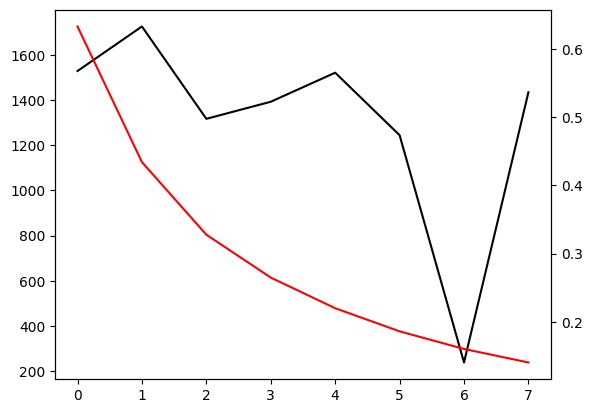

INFO mod.rs:302 2025-07-28 13:40:25,184 pf_initialize_data
	KL delta: n/a | eps: 0.648 -- 0.791 -- 0.877
	ran 0.803M evaluations in 0.04 sec


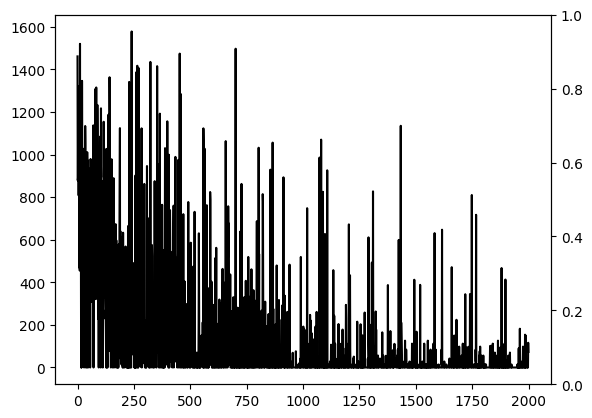

In [2]:
# Set up model priors
model = ECHModel([
    Univariate.uniform("phi", -1.0, 1.0),
    Univariate.uniform("theta", np.pi - 1.25, np.pi + 1.25),
    Univariate.constant("psi", 0.0),
    Univariate.uniform("y", -0.5, 0.5),
    Univariate.constant("delta", 1.0),
    Univariate.constant("radius", 0.11),
    Univariate.uniform("x_0", 0.25, 1.0),
    Univariate.constant("velocity", 500.0),
    Univariate.uniform("b_scale", 10, 25),
    Univariate.constant("lambda", 0.0),
    Univariate.constant("alpha", 0.0),
    Univariate.uniform("tau", 0.0, 20.0),
])

arr = np.array([
    [np.nan, np.nan, np.nan],
    [-3.13531505, -13.98423491, -6.64658269],
    [-3.38360946, -15.34720671, -1.71139834],
    [-4.21540068, -13.93568105, 4.73878965],
    [-5.41469694, -13.9772912, 4.14112123],
    [-4.30711573, -12.61217154, 5.78382821],
    [np.nan, np.nan, np.nan],
])

# set up observation scobs
scobs = MagScObs(
    [4.0 * 3600.0 * i for i in range(len(arr))],
    [[1.0, 0.0, 0.0] for _ in range(len(arr))],
    arr
)

pf_abc = model.new_pf(scobs, 2048, 43, simulation_time_limit=5, simulation_ensemble_size_factor=4, max_iterations=8)
pf_abc.mag_initialize_rmse(1.0)
particles_initial = pf_abc.particles()
noise_model = ObserVecNoise.gaussian(2.0)
result_abc = np.array(pf_abc.mag_abc_rmse(0.25, noise_model))
particles_abc = pf_abc.particles()

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(result_abc[0, :], color="k")
ax2.plot(result_abc[2, :], color="r")
plt.show()

pf_dev = model.new_pf(scobs, 2048, 42, simulation_time_limit=5, simulation_ensemble_size_factor=4, max_iterations=8)
pf_dev.mag_initialize_rmse(1.0)
result_dev = np.array(pf_dev.mag_dev_rmse(2000, 0.1, 0.9))
particles_dev = pf_dev.particles()

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(result_dev, color="k")
plt.show()

dev_min = pf_dev.particles()[0][np.argmin(pf_dev.errors())]

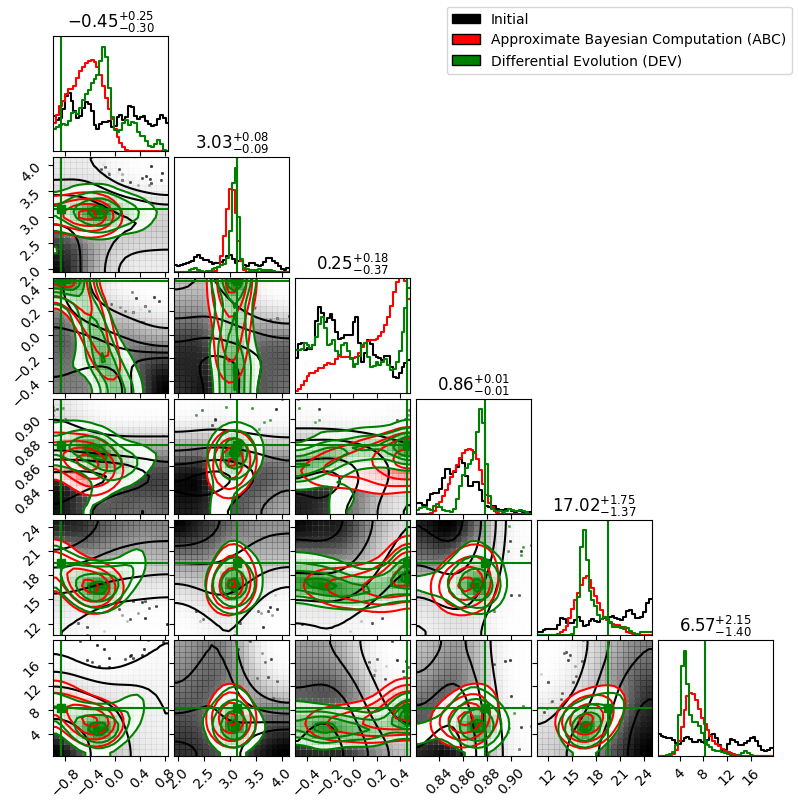

In [3]:
autorange = np.array([np.min(particles_initial[0], axis=0), np.max(particles_initial[0], axis=0)]).T
autoflag = [True for _ in autorange]

for idx in range(len(autorange)):
        if autorange[idx][0] == autorange[idx][1]:
                autoflag[idx] = False

cfig = plt.figure(figsize=(8, 8))
corner.corner(particles_initial[0].T[autoflag].T, 
              weights=particles_initial[1], color='k',
              range=autorange[autoflag], fig=cfig, smooth=5.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2)
corner.corner(particles_abc[0].T[autoflag].T, 
              weights=particles_abc[1], color='r',
              range=autorange[autoflag], fig=cfig, smooth=2.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2, show_titles=True)
corner.corner(particles_dev[0].T[autoflag].T, 
              weights=particles_dev[1], color='g',
              range=autorange[autoflag], fig=cfig, smooth=2.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2, truths=dev_min[autoflag], truth_color="g")
cfig.legend(handles=[
    Patch(facecolor='k', edgecolor='k', label="Initial"),
    Patch(facecolor='r', edgecolor='k', label="Approximate Bayesian Computation (ABC)"),
    Patch(facecolor='g', edgecolor='k', label="Differential Evolution (DEV)"),
], loc='upper right')
plt.show()

In [4]:
for i in np.array(list(range(2, 20)))[::-1] / 2:
    mat = np.diag([float(i) for _ in range(len(scobs))])
    covm = CovMatrix(mat)

    pf_abc.mag_sir_iter_mvllh(covm)
    pf_dev.mag_sir_iter_mvllh(covm)

particles_abc_sir = pf_abc.particles()
particles_dev_sir = pf_dev.particles()

INFO sir.rs:119 2025-07-28 13:40:29,595 pf_sir_iter interim ess = 1.7224414117593196
INFO sir.rs:178 2025-07-28 13:40:29,600 pf_sir_iter
	KL delta: 47.537 
	ran 0.057M evaluations in 0.07 sec
	unique samples = 82 / 2048
INFO sir.rs:119 2025-07-28 13:40:29,665 pf_sir_iter interim ess = 3.533028799185671
INFO sir.rs:178 2025-07-28 13:40:29,669 pf_sir_iter
	KL delta: 34.235 
	ran 0.057M evaluations in 0.07 sec
	unique samples = 455 / 2048
INFO sir.rs:119 2025-07-28 13:40:29,735 pf_sir_iter interim ess = 3.22594862787589
INFO sir.rs:178 2025-07-28 13:40:29,741 pf_sir_iter
	KL delta: 224.473 
	ran 0.057M evaluations in 0.07 sec
	unique samples = 84 / 2048
INFO sir.rs:119 2025-07-28 13:40:29,807 pf_sir_iter interim ess = 473.00401077809164
INFO sir.rs:178 2025-07-28 13:40:29,811 pf_sir_iter
	KL delta: 62.824 
	ran 0.057M evaluations in 0.07 sec
	unique samples = 785 / 2048
INFO sir.rs:119 2025-07-28 13:40:29,877 pf_sir_iter interim ess = 38.293656810750946
INFO sir.rs:178 2025-07-28 13:40:29

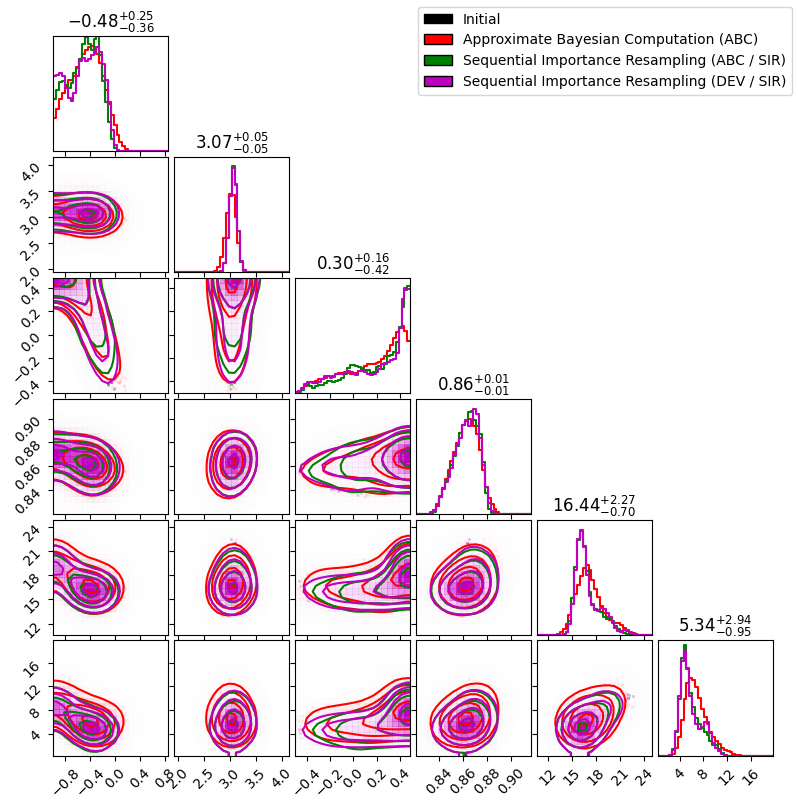

In [5]:
autorange = np.array([np.min(particles_initial[0], axis=0), np.max(particles_initial[0], axis=0)]).T
autoflag = [True for _ in autorange]

for idx in range(len(autorange)):
        if autorange[idx][0] == autorange[idx][1]:
                autoflag[idx] = False

cfig = plt.figure(figsize=(8, 8))
corner.corner(particles_abc[0].T[autoflag].T, 
              weights=particles_abc[1], color='r',
              range=autorange[autoflag], fig=cfig, smooth=2.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2, show_titles=True)
corner.corner(particles_abc_sir[0].T[autoflag].T, 
              weights=particles_abc_sir[1], color='g',
              range=autorange[autoflag], fig=cfig, smooth=2.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2, show_titles=True)
corner.corner(particles_dev_sir[0].T[autoflag].T, 
              weights=particles_dev_sir[1], color='m',
              range=autorange[autoflag], fig=cfig, smooth=2.0, 
              smooth1d=1.0, bins=20, hist_bin_factor=2, show_titles=True)
cfig.legend(handles=[
    Patch(facecolor='k', edgecolor='k', label="Initial"),
    Patch(facecolor='r', edgecolor='k', label="Approximate Bayesian Computation (ABC)"),
    Patch(facecolor='g', edgecolor='k', label="Sequential Importance Resampling (ABC / SIR)"),
    Patch(facecolor='m', edgecolor='k', label="Sequential Importance Resampling (DEV / SIR)"),
], loc='upper right')
plt.show()